# MCMC walker initialization: a silently frozen dimension

BING used to build the initial walker ball **multiplicatively**:

```python
p0 = np.tile(p0, (nwalkers, 1))
p0 += p0*np.random.uniform(-1e-2, 1e-2, size=p0.shape)
```

If any parameter is seeded at exactly `0.0`, its perturbation is also
exactly zero, so **every walker shares that coordinate**. emcee's stretch
move proposes along the vector *between* two walkers, so a dimension with
no inter-walker spread can never move -- for the entire run. Nothing
complains: the acceptance fraction stays healthy, and the posterior for
that parameter comes back as a delta function with a zero-width credible
interval.

This is not a corner case. Linear parameters legitimately sit at zero:
`Pow2`'s mineral exponent $\eta_{min}=0$ is exactly the flat ("white")
mineral backscattering that turbid water calls for, and a chi-squared fit
converges there on its own. The standard workflow then hands that
chi-squared result to the sampler as `p0`.

**The fix** (`bing.fitting.inference.init_walkers`): perturb by
`max(|p0|*frac, floor)` -- additive, floored -- then clip into the prior
bounds so every walker also starts with a finite log-probability.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
from matplotlib import pyplot as plt

from bing.fitting import inference as bing_inf
from bing.models import utils as model_utils
from bing.parameters import standard
from bing.fitting import chisq_fit
from bing.rt import defs as rt_defs

C_OLD, C_NEW = '#D55E00', '#0072B2'

def old_init_walkers(p0, nwalkers, models=None, frac=1e-2, floor=1e-3,
                     rng=None):
    """The pre-fix walker ball: purely multiplicative, no clipping."""
    p0 = np.asarray(p0, float).flatten()
    w = np.tile(p0, (nwalkers, 1))
    return w + w*np.random.uniform(-frac, frac, size=w.shape)

# ExpBricaud + Pow2.  eta_min = 0 exactly -- a flat mineral term.
PNAMES = ['Adg', 'Sdg', 'Aph', 'Bmin', 'eta_min', 'Borg', 'eta_org']
P0 = np.array([-1.0, 0.015, -0.7, -1.3, 0.0, -1.0, 1.8])
IZERO = PNAMES.index('eta_min')
print('p0 =', dict(zip(PNAMES, P0)))

p0 = {'Adg': np.float64(-1.0), 'Sdg': np.float64(0.015), 'Aph': np.float64(-0.7), 'Bmin': np.float64(-1.3), 'eta_min': np.float64(0.0), 'Borg': np.float64(-1.0), 'eta_org': np.float64(1.8)}


## 1. The walker ball itself

Spread across walkers, per parameter. Zero spread means a dead dimension.

In [2]:
np.random.seed(42)
w_old = old_init_walkers(P0, 64)
np.random.seed(42)
w_new = bing_inf.init_walkers(P0, 64)

print(f'{"param":9s} {"p0":>8s} {"OLD spread":>12s} {"NEW spread":>12s}')
for k, nm in enumerate(PNAMES):
    print(f'{nm:9s} {P0[k]:8.3f} {w_old[:, k].std():12.2e} '
          f'{w_new[:, k].std():12.2e}')
print()
print('OLD dead dimensions:', [PNAMES[k] for k in range(len(PNAMES))
                               if w_old[:, k].std() == 0.])
print('NEW dead dimensions:', [PNAMES[k] for k in range(len(PNAMES))
                               if w_new[:, k].std() == 0.])

param           p0   OLD spread   NEW spread
Adg         -1.000     6.05e-03     6.05e-03
Sdg          0.015     8.12e-05     5.42e-04
Aph         -0.700     4.15e-03     4.15e-03
Bmin        -1.300     8.03e-03     8.03e-03
eta_min      0.000     0.00e+00     5.79e-04
Borg        -1.000     5.68e-03     5.68e-03
eta_org      1.800     1.10e-02     1.10e-02

OLD dead dimensions: ['eta_min']
NEW dead dimensions: []


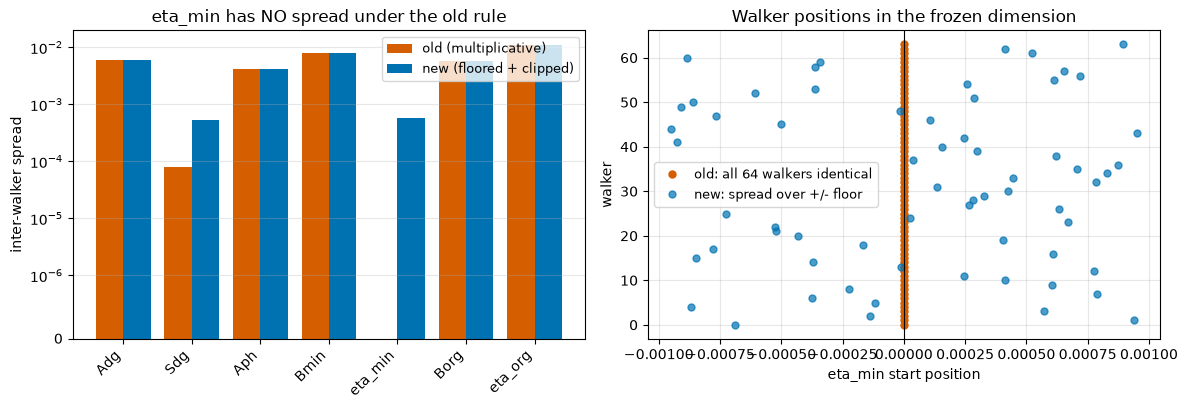

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axs[0]
x = np.arange(len(PNAMES))
ax.bar(x - 0.2, [w_old[:, k].std() for k in x], 0.4, color=C_OLD,
       label='old (multiplicative)')
ax.bar(x + 0.2, [w_new[:, k].std() for k in x], 0.4, color=C_NEW,
       label='new (floored + clipped)')
ax.set_yscale('symlog', linthresh=1e-6)
ax.set_xticks(x)
ax.set_xticklabels(PNAMES, rotation=45, ha='right')
ax.set_ylabel('inter-walker spread')
ax.set_title('eta_min has NO spread under the old rule')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')

ax = axs[1]
ax.plot(w_old[:, IZERO], np.arange(64), 'o', ms=5, color=C_OLD,
        label='old: all 64 walkers identical')
ax.plot(w_new[:, IZERO], np.arange(64), 'o', ms=5, color=C_NEW,
        alpha=0.7, label='new: spread over +/- floor')
ax.axvline(0., color='k', lw=0.8)
ax.set_xlabel('eta_min start position')
ax.set_ylabel('walker')
ax.set_title('Walker positions in the frozen dimension')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. What it does to a real chain

Same synthetic spectrum, same seed, 250 steps: once with each
initialization. Watch `eta_min`.

In [4]:
wv = np.arange(400., 705., 5.)
p = standard.expb_pow2(wv_min=400., wv_max=700., variable_Gordon=False)
models = model_utils.init(p.model_names, wv, (p.apriors, p.bpriors))
models[0].set_aph(np.array([1.0]))
rt_dict = rt_defs.rt_dict_from_p(p)

Rrs = chisq_fit.fit_func(wv, *P0, models=models, rt_dict=rt_dict)
varRrs = (0.02*Rrs)**2

chains = {}
saved = bing_inf.init_walkers
for label, initf in [('old', old_init_walkers), ('new', None)]:
    bing_inf.init_walkers = initf if initf is not None else saved
    np.random.seed(7)
    sampler = bing_inf.run_emcee(models, Rrs, varRrs, rt_dict,
                                 nwalkers=16, nburn=50, nsteps=250,
                                 skip_check=True, p0=P0.copy())
    bing_inf.init_walkers = saved
    chains[label] = sampler.get_chain()
    acc = float(np.mean(sampler.acceptance_fraction))
    spread = chains[label].reshape(-1, len(PNAMES)).std(axis=0)
    print(f'{label}: acceptance = {acc:.2f} (healthy either way), '
          f'eta_min spread = {spread[IZERO]:.3e}')

Running burn-in


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:00<00:00, 1274.95it/s]

Running full model


  0%|          | 0/250 [00:00<?, ?it/s]

...

  0%|          | 0/250 [00:00<?, ?it/s]

 50%|████▉     | 124/250 [00:00<00:00, 1230.99it/s]

 99%|█████████▉| 248/250 [00:00<00:00, 1169.85it/s]

100%|██████████| 250/250 [00:00<00:00, 1158.62it/s]

new: acceptance = 0.33 (healthy either way), eta_min spread = 5.754e-02


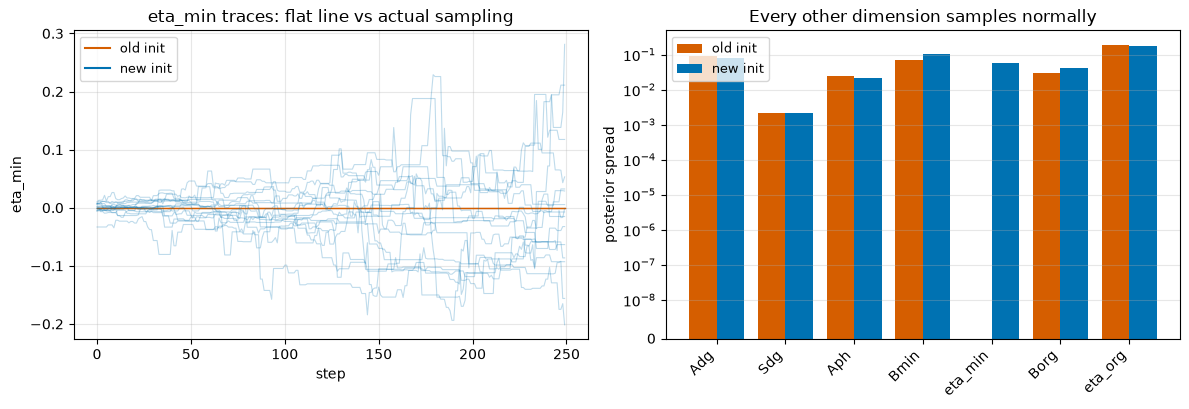

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axs[0]
for label, clr in [('old', C_OLD), ('new', C_NEW)]:
    ax.plot(chains[label][:, :, IZERO], color=clr, alpha=0.25, lw=0.8)
    ax.plot([], [], color=clr, label=f'{label} init')
ax.set_xlabel('step')
ax.set_ylabel('eta_min')
ax.set_title('eta_min traces: flat line vs actual sampling')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axs[1]
x = np.arange(len(PNAMES))
for off, (label, clr) in zip((-0.2, 0.2),
                             [('old', C_OLD), ('new', C_NEW)]):
    sp = chains[label].reshape(-1, len(PNAMES)).std(axis=0)
    ax.bar(x + off, sp, 0.4, color=clr, label=f'{label} init')
ax.set_yscale('symlog', linthresh=1e-8)
ax.set_xticks(x)
ax.set_xticklabels(PNAMES, rotation=45, ha='right')
ax.set_ylabel('posterior spread')
ax.set_title('Every other dimension samples normally')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

The old chain reports `eta_min` as *perfectly determined* -- a zero-width
credible interval at whatever the chi-squared fit happened to return --
while its acceptance fraction looks entirely normal. That is the failure
mode: not a crash, a confidently wrong uncertainty.

## 3. Does the fix disturb existing results?

It has to be checked, because the change touches **every** MCMC run. The
honest test is to compare old-vs-new against each method's own
**run-to-run scatter**: MCMC medians move between seeds anyway, so a
difference only matters if it exceeds that.

`expb_pow` on L23 idx 170, 8000 steps, two seeds per method (~2 min).

In [6]:
from bing.fitting import l23 as fit_l23
import emcee

p_l23 = standard.expb_pow(satellite='PACE', nsteps=8000, nburn=1000)
runs = {}
saved = bing_inf.init_walkers
for label, initf, seed in [('OLD-a', old_init_walkers, 11),
                           ('OLD-b', old_init_walkers, 22),
                           ('NEW-a', None, 11), ('NEW-b', None, 22)]:
    bing_inf.init_walkers = initf if initf is not None else saved
    np.random.seed(seed)
    ch, mdl, _, _, _ = fit_l23.fit_one(p_l23, idx=170)
    bing_inf.init_walkers = saved
    flat = ch.reshape(-1, ch.shape[-1])
    act = float(np.max(emcee.autocorr.integrated_time(ch, quiet=True)))
    runs[label] = dict(med=np.median(flat, axis=0), act=act,
                       ci=np.diff(np.percentile(flat, [5, 95], axis=0),
                                  axis=0)[0])
names_l23 = list(mdl[0].pnames) + list(mdl[1].pnames)

hdr = '  '.join(f'{n:>8s}' for n in names_l23)
print(f'{"run":6s} {hdr}   max ACT')
for label, r in runs.items():
    print(f'{label:6s} ' + '  '.join(f'{v:+8.4f}' for v in r['med']) +
          f'   {r["act"]:7.0f}')

idx=170
Running burn-in


  0%|          | 0/1000 [00:00<?, ?it/s]

 14%|█▍        | 139/1000 [00:00<00:00, 1385.94it/s]

 34%|███▎      | 337/1000 [00:00<00:00, 1732.10it/s]

 52%|█████▏    | 518/1000 [00:00<00:00, 1765.76it/s]

...

 95%|█████████▍| 7599/8000 [00:03<00:00, 2361.19it/s]

 98%|█████████▊| 7842/8000 [00:03<00:00, 2380.96it/s]

100%|██████████| 8000/8000 [00:03<00:00, 2173.38it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 160;
tau: [413.99935296 342.12416753 438.98353333 129.5657131  176.04837204]


run         Adg       Sdg       Aph       Bnw      beta   max ACT
OLD-a   -1.6419   +0.0135   -2.1727   -3.5119   +0.9885       400
OLD-b   -1.6362   +0.0133   -2.1817   -3.5129   +0.9863       438
NEW-a   -1.6447   +0.0137   -2.1510   -3.5153   +0.9669       413
NEW-b   -1.6424   +0.0136   -2.1605   -3.5114   +1.0034       439


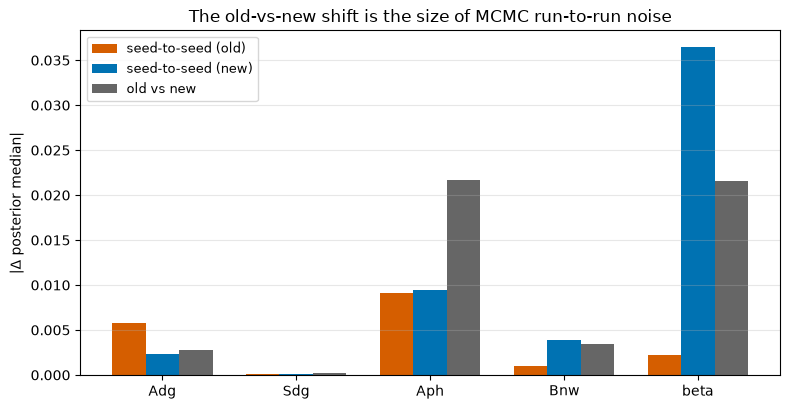

Sdg posterior median across all four runs: [0.01345 0.01333 0.01371 0.0136 ]
  (its initial ball is ~7x wider now, and the posterior is unchanged)


In [7]:
seed_old = np.abs(runs['OLD-a']['med'] - runs['OLD-b']['med'])
seed_new = np.abs(runs['NEW-a']['med'] - runs['NEW-b']['med'])
cross = np.abs(runs['OLD-a']['med'] - runs['NEW-a']['med'])

fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(names_l23))
ax.bar(x - 0.25, seed_old, 0.25, color=C_OLD, label='seed-to-seed (old)')
ax.bar(x, seed_new, 0.25, color=C_NEW, label='seed-to-seed (new)')
ax.bar(x + 0.25, cross, 0.25, color='0.4', label='old vs new')
ax.set_xticks(x)
ax.set_xticklabels(names_l23)
ax.set_ylabel(r'$|\Delta$ posterior median$|$')
ax.set_title('The old-vs-new shift is the size of MCMC run-to-run noise')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('Sdg posterior median across all four runs:',
      np.round([runs[k]['med'][1] for k in runs], 5))
print('  (its initial ball is ~7x wider now, and the posterior is'
      ' unchanged)')

## Summary

- A parameter seeded at exactly 0 was **frozen for the whole run**, and
  nothing in the diagnostics showed it.
- The floored, clipped ball fixes that, and additionally guarantees every
  walker starts in-prior.
- For well-scaled parameters the ball is *identical* to the historical 1%
  one, so existing L23 posteriors move only within run-to-run MCMC
  scatter, with unchanged autocorrelation time.
- The default RNG is deliberately still the legacy global `np.random`, so
  `bing.fitting.l23.batch_fit(seed=...)` stays reproducible.

`run_emcee` exposes `perturb_frac` / `perturb_floor` for models that need
a wider starting ball.